### 3. Modelo SARIMA

El modelo SARIMA (Seasonal ARIMA) es una extensión del modelo ARIMA el cual incorpora explícitamente la componente de estacionalidad. Se expresa como:

SARIMA(p,d,q)(P,D,Q,s)

donde:

(p,d,q) representan los componentes no estacionales y (P,D,Q) representan los componentes estacionales.

s indica el periodo de la estacionalidad (por ejemplo, 24 para datos horarios diarios).

Este modelo resulta especialmente adecuado para el mercado eléctrico, ya que el precio de la electricidad presenta patrones periódicos claros, como la variación diaria de la demanda y los ciclos semanales.

### Ejemplo código python:

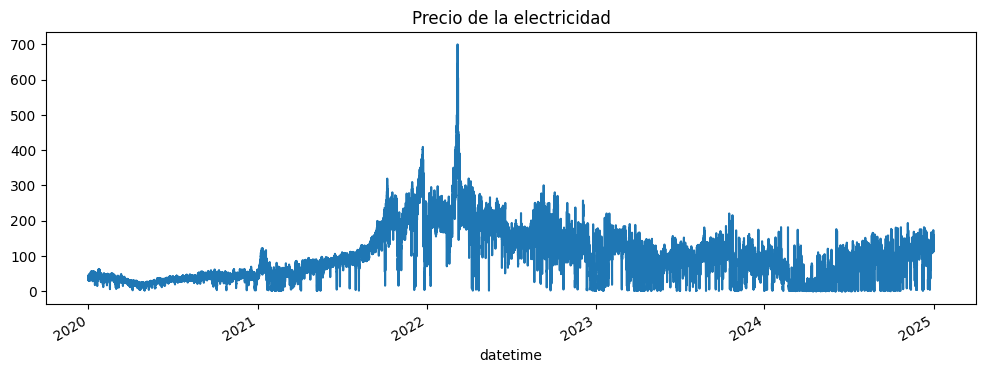

c:\entornos\tfg_env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\entornos\tfg_env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                              price   No. Observations:                45675
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 24)   Log Likelihood             -166002.314
Date:                            Mon, 23 Mar 2026   AIC                         332014.627
Time:                                    19:28:03   BIC                         332058.268
Sample:                                         0   HQIC                        332028.356
                                          - 45675                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1215      0.009     13.774      0.000       0.104       0.139
ma.L1          0.2079      0.009   

c:\entornos\tfg_env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\entornos\tfg_env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


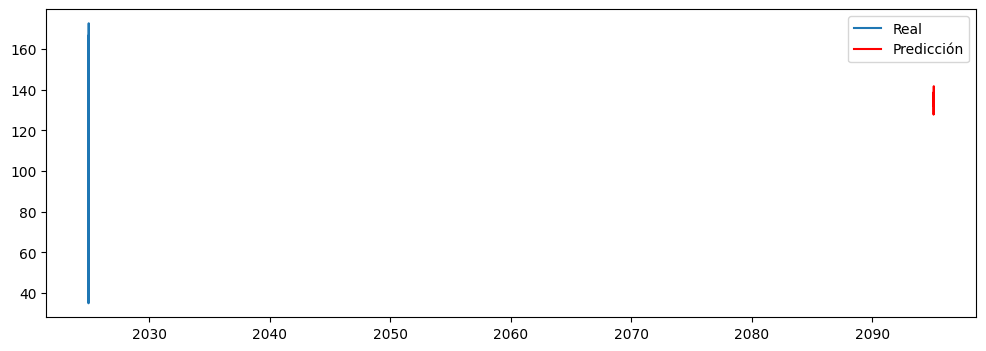

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Ejemplo: dataframe con columnas ['datetime', 'price']
df = pd.read_csv("precio_luz.csv", sep=";")

df["datetime"] = pd.to_datetime(df["datetime"])
df = df.set_index("datetime")

# Visualizar
df["price"].plot(figsize=(12,4))
plt.title("Precio de la electricidad")
plt.show()

from statsmodels.tsa.statespace.sarimax import SARIMAX

model_sarima = SARIMAX(
    df["price"],
    order=(1,1,1),
    seasonal_order=(1,1,1,24),
    enforce_stationarity=False,
    enforce_invertibility=False
)

result_sarima = model_sarima.fit()

print(result_sarima.summary())

# Predecir próximas 24 horas
forecast = result_sarima.forecast(steps=24)

plt.figure(figsize=(12,4))
plt.plot(df["price"][-200:], label="Real")
plt.plot(forecast, label="Predicción", color="red")
plt.legend()
plt.show()

